In [1]:
import numpy as np
import matplotlib.pyplot as plt
from TMS_deltaT_functions_github import C_Delta_T
from TMS_deltaT_functions_github import Weights_subBands


Ruta completa del archivo: general_documents/data_files/input_params_simulation_V1_def.toml
Archivo cargado correctamente


/home/aarriero/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
array1_tiempo = (29999,)
t_sky_r=8*np.ones((29999, 1000))

freq_spec=np.linspace(10,19.99,1000)
min_arr=((freq_spec[1]-freq_spec[0])/2)+freq_spec[0]
max_arr=freq_spec[np.size(freq_spec)-1]-((freq_spec[1]-freq_spec[0])/2)
arra_freq_new=np.linspace(min_arr,max_arr,40)
x = arra_freq_new


In [3]:
(   
        total_BEM_atmos_cmb, 
        total_I1_BEM_atmos_cmb, 
        total_I2_BEM_atmos_cmb,
        freq_spec, 
        Tlss_resta,
        T_sky_bet_total, 
        T_load_bet_total

    )=C_Delta_T(array1_tiempo, t_sky_r, step=100,ideal=0,scatter=0)


(
        band_pass_prom_t,
        band_pass_prom_t_I1,
        band_pass_prom_t_I2,
        band_pass_prom_t_betasky,
        band_pass_prom_t_betaload,
        band_pass_prom_t_Tlss_resta,


    )=Weights_subBands(array1_tiempo, freq_spec, total_BEM_atmos_cmb,
                     total_I1_BEM_atmos_cmb, total_I2_BEM_atmos_cmb,
                     T_sky_bet_total, T_load_bet_total,
                     Tlss_resta)




This is the case for the results in the paper: if input 8, Delta T = 6.91 K
###########################################################################
######################################################################################
Table_C1:WINDOW 7.11171178320597
Table_C1:IRF 0.6341411811554792
Table_C1:FHsky 0.13057692942861246
Table_C1:OMTsky 0.4252379107932325
Table_C1:HYbsky 0.14728508639812546
######################################################################################
Table_C1:FHload 0.12580118638205132
Table_C1:OMTload 0.4096875122453929
Table_C1:HYbload 0.14189726161534255


In [4]:
print('np.mean(Delta T)',np.mean(total_BEM_atmos_cmb[0]))
print('np.std(Delta T)',np.std(total_BEM_atmos_cmb[0]))

np.mean(Delta T) 6.91486152486591
np.std(Delta T) 0.0937758550690808


/tmp/ipykernel_96003/3030091906.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=10, frameon=True, shadow=True, fancybox=True)


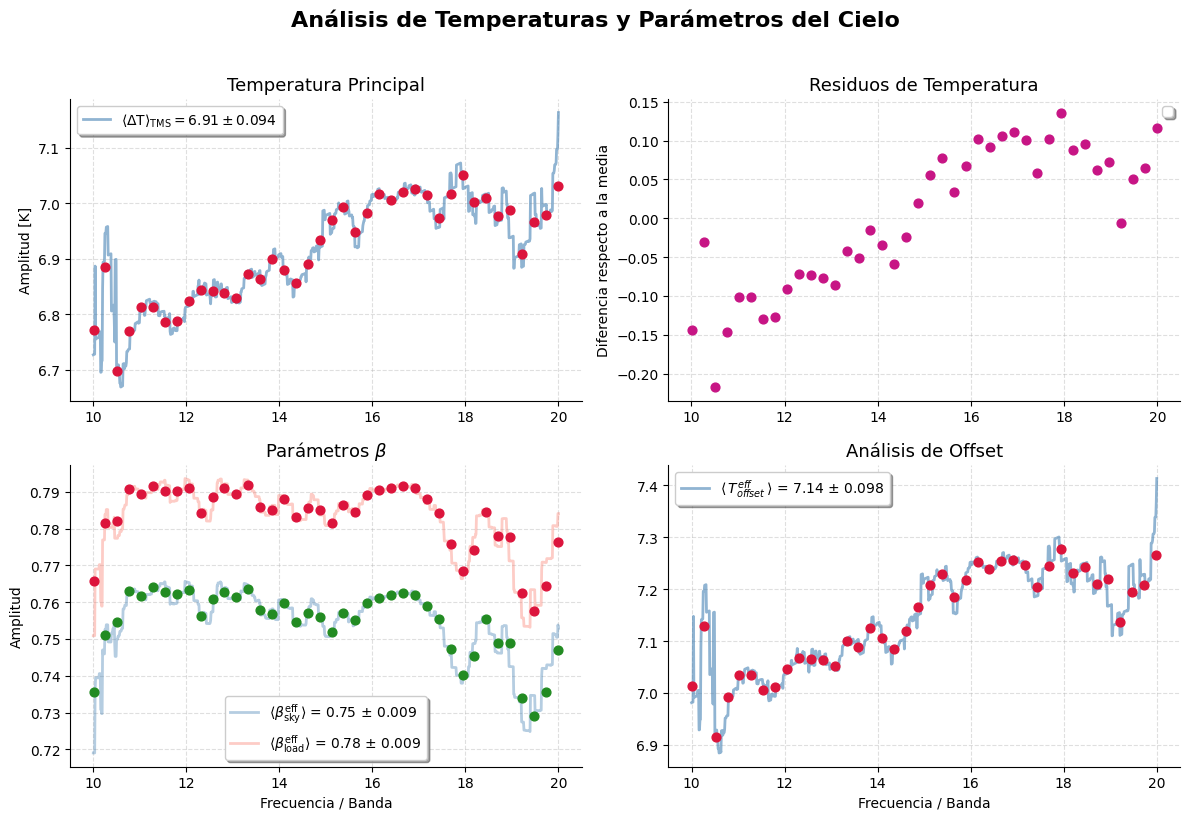

In [5]:
# 1. Configuración de estilo global (Limpia el fondo y añade grid)
plt.rcParams.update({
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

# 2. Inicialización de la figura (Un poco más grande y con más resolución)
fig, axs = plt.subplots(2, 2, figsize=(12, 8), dpi=100)
fig.suptitle('Análisis de Temperaturas y Parámetros del Cielo', fontsize=16, fontweight='bold', y=1.02)
axs = axs.flatten()

# 3. Paleta de colores profesional (evitamos los colores básicos 'r', 'b', 'g')
c_line1 = 'steelblue'
c_line2 = 'salmon'
c_scatter1 = 'crimson'
c_scatter2 = 'forestgreen'
c_diff = 'mediumvioletred'

# --- SUBPLOT 0: Delta T ---
axs[0].plot(freq_spec[0], total_BEM_atmos_cmb[0], label=r'$\rm \langle \Delta T \rangle_{\rm TMS} = %.2f \pm %.3f$' % (np.mean(total_BEM_atmos_cmb[0]), np.std(total_BEM_atmos_cmb[0])), color=c_line1, alpha=0.6, linewidth=2)
axs[0].scatter(x, band_pass_prom_t[0], color=c_scatter1, zorder=3, s=40)
axs[0].set_title('Temperatura Principal', fontsize=13)
axs[0].set_ylabel('Amplitud [K]') # Ajusta las unidades si son otras

# --- SUBPLOT 1: T Sub ---
axs[1].scatter(x, band_pass_prom_t[0] - np.mean(total_BEM_atmos_cmb[0]), color=c_diff, zorder=3, s=40)
axs[1].set_title('Residuos de Temperatura', fontsize=13)
axs[1].set_ylabel('Diferencia respecto a la media')

# --- SUBPLOT 2: Beta Sky & Load ---
axs[2].plot(freq_spec[0], T_sky_bet_total, label=r'$\langle \beta_{\rm sky}^{\rm eff} \rangle$ = %.2f $\pm$ %.3f' % (np.mean(T_sky_bet_total), np.std(T_sky_bet_total)), color=c_line1, alpha=0.4, linewidth=2)
axs[2].plot(freq_spec[0], T_load_bet_total, label=r'$ \langle \beta_{\rm load}^{\rm eff} \rangle$ = %.2f $\pm$ %.3f' % (np.mean(T_load_bet_total),np.std(T_load_bet_total)), color=c_line2, alpha=0.4, linewidth=2)
axs[2].scatter(x, band_pass_prom_t_betasky, color=c_scatter2, zorder=3, s=40)
axs[2].scatter(x, band_pass_prom_t_betaload, color=c_scatter1, zorder=3, s=40)
axs[2].set_title(r'Parámetros $\beta$', fontsize=13)
axs[2].set_xlabel('Frecuencia / Banda')
axs[2].set_ylabel('Amplitud')

# --- SUBPLOT 3: T Offset ---
axs[3].plot(freq_spec[0], Tlss_resta[0], label=r'$ \langle \, T^{eff}_{offset} \, \rangle $ = %.2f $\pm$ %.3f' % (np.mean(Tlss_resta[0]), np.std(Tlss_resta[0])), color=c_line1, alpha=0.6, linewidth=2)
axs[3].scatter(x, band_pass_prom_t_Tlss_resta[0], color=c_scatter1, zorder=3, s=40)
axs[3].set_title('Análisis de Offset', fontsize=13)
axs[3].set_xlabel('Frecuencia / Banda')

for ax in axs:
    ax.legend(loc='best', fontsize=10, frameon=True, shadow=True, fancybox=True)

plt.tight_layout()
plt.show()